# 01 - Exploratory Data Analysis: Urban & Rural Sets

Side-by-side EDA of the urban training set and rural test set.
All plots are produced as paired comparisons to highlight distribution shift.

| Dataset | Rows | Fatal accidents | Fatality rate |
|---|---|---|---|
| Urban (train) | 3,544 | 64 | 1.81% |
| Rural (test)  | 1,421 | 70 | 4.93% |

**Sections**
1. Dataset overview
2. Target variable
3. Accident types (broad)
4. Accident types (detailed)
5. Lighting conditions
6. Temporal distribution
7. Road width
8. Speed limit
9. Feature shift summary

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

In [2]:
from google.colab import drive
#drive.flush_and_unmount()
drive.mount('/content/drive')

path_urban = '/content/drive/MyDrive/Analytics course/urban_set.csv'
urban = pd.read_csv(path_urban, parse_dates=['accident_time'])

path_rural = '/content/drive/MyDrive/Analytics course/rural_set.csv'
rural = pd.read_csv(path_rural, parse_dates=['accident_time'])

Mounted at /content/drive


In [3]:
'''# -- Data paths -- update to your local environment
DATA_DIR   = '../data/'
urban_path = DATA_DIR + 'urban_filter.csv'
rural_path = DATA_DIR + 'rural_filter.csv'

urban = pd.read_csv(urban_path, parse_dates=['accident_time'])
rural = pd.read_csv(rural_path, parse_dates=['accident_time'])

print(f'Urban: {urban.shape}  |  Rural: {rural.shape}')'''

"# -- Data paths -- update to your local environment\nDATA_DIR   = '../data/'\nurban_path = DATA_DIR + 'urban_filter.csv'\nrural_path = DATA_DIR + 'rural_filter.csv'\n\nurban = pd.read_csv(urban_path, parse_dates=['accident_time'])\nrural = pd.read_csv(rural_path, parse_dates=['accident_time'])\n\nprint(f'Urban: {urban.shape}  |  Rural: {rural.shape}')"

In [4]:
for df in [urban, rural]:
    df['is_fatal']       = (df['deaths'] > 0).astype(int)
    df['hour']           = df['accident_time'].dt.hour
    df['month']          = df['accident_time'].dt.month
    df['year']           = df['accident_time'].dt.year
    df['day_of_week']    = df['accident_time'].dt.dayofweek
    df['road_width_bin'] = pd.cut(
        df['road_width'],
        bins=[0, 5, 9, 14, 99],
        labels=['Narrow (3-5m)', 'Standard (6-9m)', 'Wide (10-14m)', 'Arterial (15m+)']
    )
    df['speed_limit'] = df['speed_limit'].replace(
        {5: 20, 10: 20, 15: 20, 25: 30, 45: 40, 60: 70, 80: 70}
    )

datasets = {'Urban (train)': urban, 'Rural (test)': rural}
colors   = {'Urban (train)': '#4C72B0', 'Rural (test)': '#DD8452'}

## 1. Dataset Overview

In [5]:
for name, df in datasets.items():
    print(f'=== {name} ===')
    print(f'Shape:           {df.shape}')
    print(f'Date range:      {df["accident_time"].min().date()} -> {df["accident_time"].max().date()}')
    print(f'Fatal accidents: {df["is_fatal"].sum():,} ({df["is_fatal"].mean():.1%})')
    print(f'Total deaths:    {df["deaths"].sum():,}')
    print(f'Total injured:   {df["injured"].sum():,}')
    nulls = df.isnull().sum()
    nulls = nulls[nulls > 0].sort_values(ascending=False)
    print(f'Columns with nulls:\n{nulls if len(nulls) else "  None"}')
    print()

=== Urban (train) ===
Shape:           (3544, 33)
Date range:      2018-01-01 -> 2025-12-30
Fatal accidents: 64 (1.8%)
Total deaths:    67
Total injured:   4,050
Columns with nulls:
  None

=== Rural (test) ===
Shape:           (1421, 33)
Date range:      2018-01-05 -> 2025-12-26
Fatal accidents: 70 (4.9%)
Total deaths:    72
Total injured:   1,673
Columns with nulls:
  None



In [6]:
numeric_cols = ['deaths', 'injured', 'road_width', 'speed_limit', 'join_distance']
for name, df in datasets.items():
    print(f'=== {name} -- numeric summary ===')
    print(df[numeric_cols].describe().round(2))
    print()

=== Urban (train) -- numeric summary ===
         deaths   injured  road_width  speed_limit  join_distance
count 3544.0000 3544.0000   3544.0000    3544.0000      3544.0000
mean     0.0200    1.1400      9.1900      47.3100         2.2800
std      0.1400    0.6100      4.1900       9.4900         3.0700
min      0.0000    0.0000      3.0000      20.0000         0.0000
25%      0.0000    1.0000      6.0000      50.0000         0.3100
50%      0.0000    1.0000      8.0000      50.0000         1.0500
75%      0.0000    1.0000     11.0000      50.0000         2.7800
max      2.0000   15.0000     25.0000      70.0000        14.9700

=== Rural (test) -- numeric summary ===
         deaths   injured  road_width  speed_limit  join_distance
count 1421.0000 1421.0000   1421.0000    1421.0000      1421.0000
mean     0.0500    1.1800      8.3000      54.3200         0.9600
std      0.2300    0.6200      2.9000      12.6700         2.3700
min      0.0000    0.0000      3.0000      20.0000         0

In [7]:
cat_cols = [
    'county', 'municipality', 'settlement',
    'accident_type', 'accident_type_detailed',
    'road_type', 'road_type_detailed',
    'road_condition', 'road_surface_condition',
    'weather', 'lighting'
]
for name, df in datasets.items():
    print(f'=== {name} -- categorical summary ===')
    for col in cat_cols:
        if col not in df.columns:
            continue
        n   = df[col].nunique()
        top = df[col].value_counts().head(3).index.tolist()
        print(f'  {col:35s} {n:3d} unique  |  top: {top}')
    print()

=== Urban (train) -- categorical summary ===
  county                                9 unique  |  top: ['Harju maakond', 'Tartu maakond', 'Ida-Viru maakond']
  municipality                         14 unique  |  top: ['Tallinn', 'Tartu linn', 'Pärnu linn']
  settlement                           22 unique  |  top: ['Kesklinna linnaosa', 'Lasnamäe linnaosa', 'Mustamäe linnaosa']
  accident_type                         3 unique  |  top: ['Kokkupõrge', 'Jalakäijaõnnetus', 'Ühesõidukiõnnetus']
  accident_type_detailed               10 unique  |  top: ['Kokkupõrge sõidukiga küljelt', 'Kokkupõrge jalakäijaga', 'Kokkupõrge ees liikuva sõidukiga']
  road_type                             2 unique  |  top: ['KOV tee/tänav', 'Riigitee']
  road_type_detailed                    7 unique  |  top: ['Tänav', 'Õuealatee', 'Põhimaantee']
  road_condition                       20 unique  |  top: ['Sõidutee on korras', 'Sõidutee on libe', 'Sõidutee on ebatasane']
  road_surface_condition               14 un

## 2. Target Variable

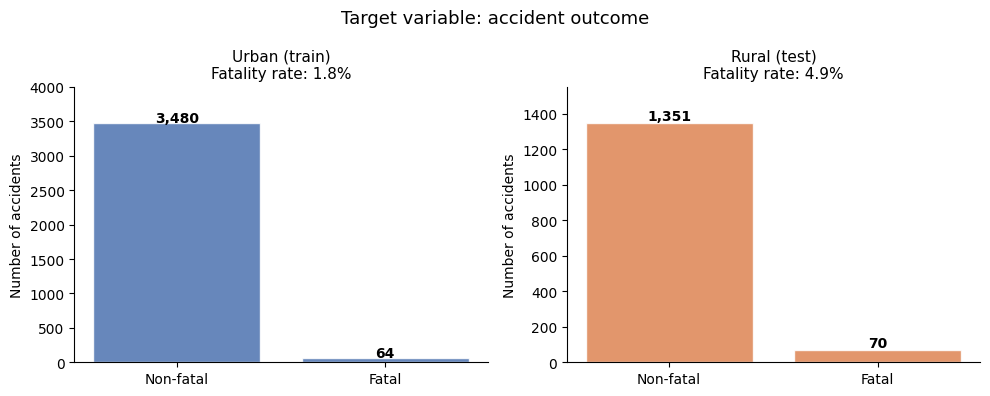

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, (name, df) in zip(axes, datasets.items()):
    counts = df['is_fatal'].value_counts().sort_index()
    bars = ax.bar(['Non-fatal', 'Fatal'], counts.values,
                  color=colors[name], edgecolor='white', alpha=0.85)
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
                f'{val:,}', ha='center', fontsize=10, fontweight='bold')
    ax.set_title(f'{name}\nFatality rate: {df["is_fatal"].mean():.1%}', fontsize=11)
    ax.set_ylabel('Number of accidents')
    ax.set_ylim(0, counts.max() * 1.15)
    sns.despine(ax=ax)

plt.suptitle('Target variable: accident outcome', fontsize=13)
plt.tight_layout()
plt.savefig('eda_01_target.png', bbox_inches='tight')
plt.show()

## 3. Accident Types (Broad)

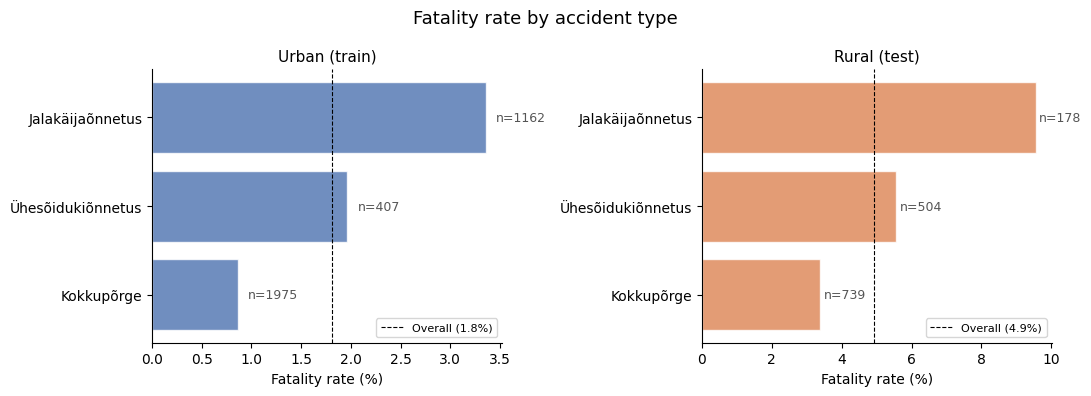

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, (name, df) in zip(axes, datasets.items()):
    rate = (df.groupby('accident_type')['is_fatal']
              .agg(['mean', 'count'])
              .rename(columns={'mean': 'fatality_rate', 'count': 'n'})
              .sort_values('fatality_rate', ascending=True))

    bars = ax.barh(rate.index, rate['fatality_rate'] * 100,
                   color=colors[name], alpha=0.8, edgecolor='white')
    for bar, (_, row) in zip(bars, rate.iterrows()):
        ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                f'n={int(row["n"])}', va='center', fontsize=9, color='#555')
    ax.axvline(df['is_fatal'].mean() * 100, color='black', linestyle='--',
               linewidth=0.8, label=f'Overall ({df["is_fatal"].mean():.1%})')
    ax.set_xlabel('Fatality rate (%)')
    ax.set_title(name, fontsize=11)
    ax.legend(fontsize=8)
    sns.despine(ax=ax)

plt.suptitle('Fatality rate by accident type', fontsize=13)
plt.tight_layout()
plt.savefig('eda_02_accident_type.png', bbox_inches='tight')
plt.show()

## 4. Accident Types (Detailed)

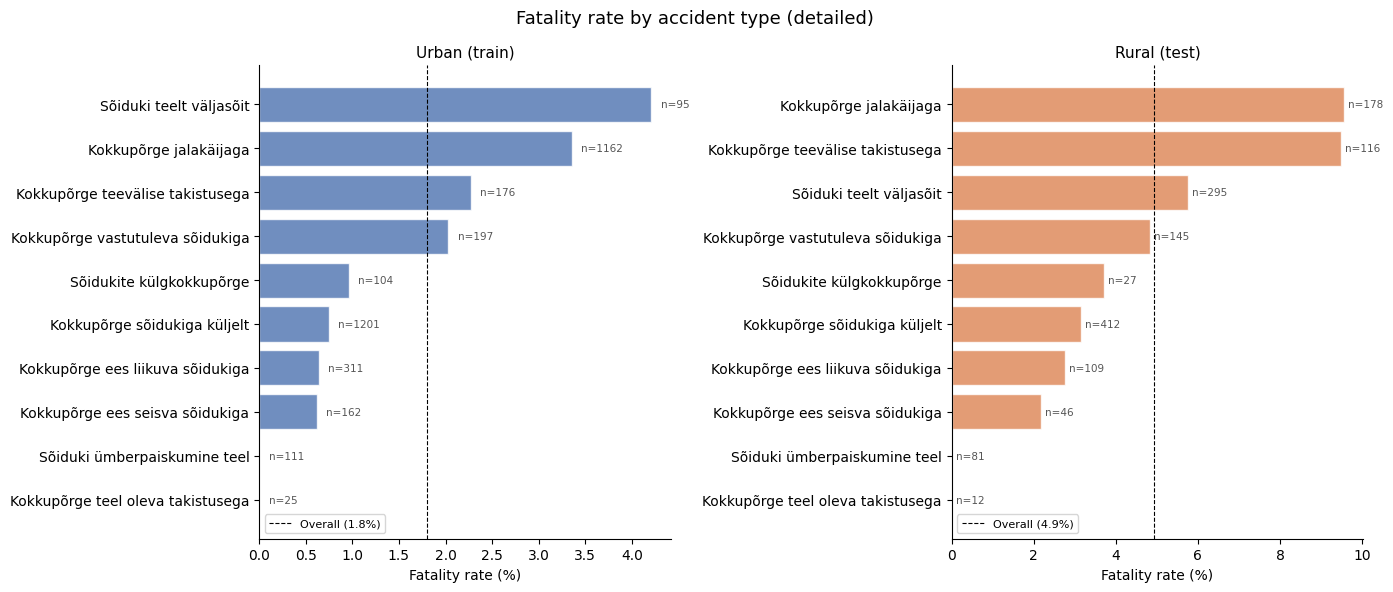

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (name, df) in zip(axes, datasets.items()):
    rate = (df.groupby('accident_type_detailed')['is_fatal']
              .agg(['mean', 'count'])
              .rename(columns={'mean': 'fatality_rate', 'count': 'n'})
              .sort_values('fatality_rate', ascending=True))

    bars = ax.barh(rate.index, rate['fatality_rate'] * 100,
                   color=colors[name], alpha=0.8, edgecolor='white')
    for bar, (_, row) in zip(bars, rate.iterrows()):
        ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                f'n={int(row["n"])}', va='center', fontsize=7.5, color='#555')
    ax.axvline(df['is_fatal'].mean() * 100, color='black', linestyle='--',
               linewidth=0.8, label=f'Overall ({df["is_fatal"].mean():.1%})')
    ax.set_xlabel('Fatality rate (%)')
    ax.set_title(name, fontsize=11)
    ax.legend(fontsize=8)
    sns.despine(ax=ax)

plt.suptitle('Fatality rate by accident type (detailed)', fontsize=13)
plt.tight_layout()
plt.savefig('eda_03_accident_type_detailed.png', bbox_inches='tight')
plt.show()

## 5. Lighting Conditions

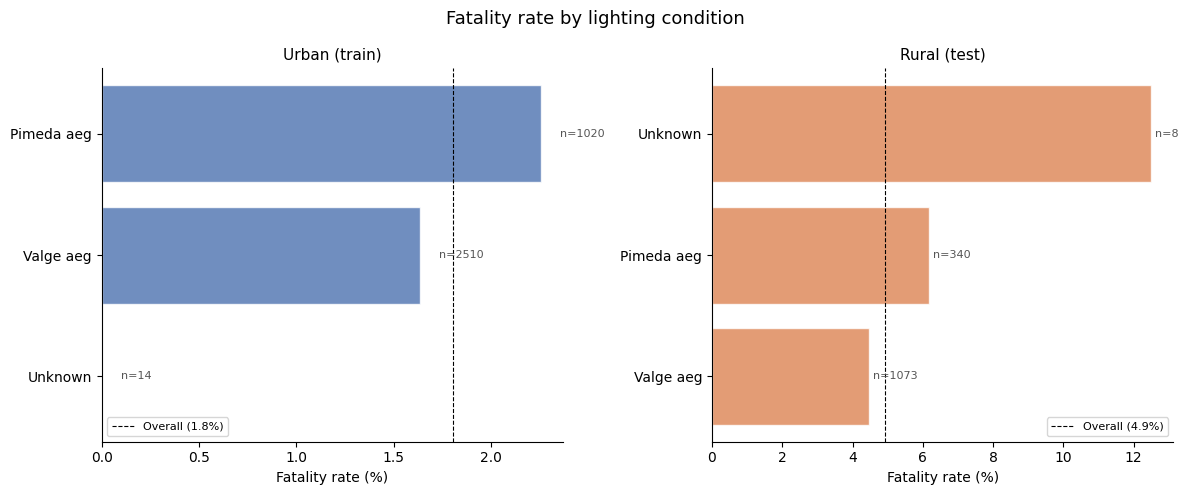

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (name, df) in zip(axes, datasets.items()):
    rate = (df.groupby('lighting')['is_fatal']
              .agg(['mean', 'count'])
              .rename(columns={'mean': 'fatality_rate', 'count': 'n'})
              .sort_values('fatality_rate', ascending=True))

    bars = ax.barh(rate.index, rate['fatality_rate'] * 100,
                   color=colors[name], alpha=0.8, edgecolor='white')
    for bar, (_, row) in zip(bars, rate.iterrows()):
        ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                f'n={int(row["n"])}', va='center', fontsize=8, color='#555')
    ax.axvline(df['is_fatal'].mean() * 100, color='black', linestyle='--',
               linewidth=0.8, label=f'Overall ({df["is_fatal"].mean():.1%})')
    ax.set_xlabel('Fatality rate (%)')
    ax.set_title(name, fontsize=11)
    ax.legend(fontsize=8)
    sns.despine(ax=ax)

plt.suptitle('Fatality rate by lighting condition', fontsize=13)
plt.tight_layout()
plt.savefig('eda_04_lighting.png', bbox_inches='tight')
plt.show()

## 6. Temporal Distribution

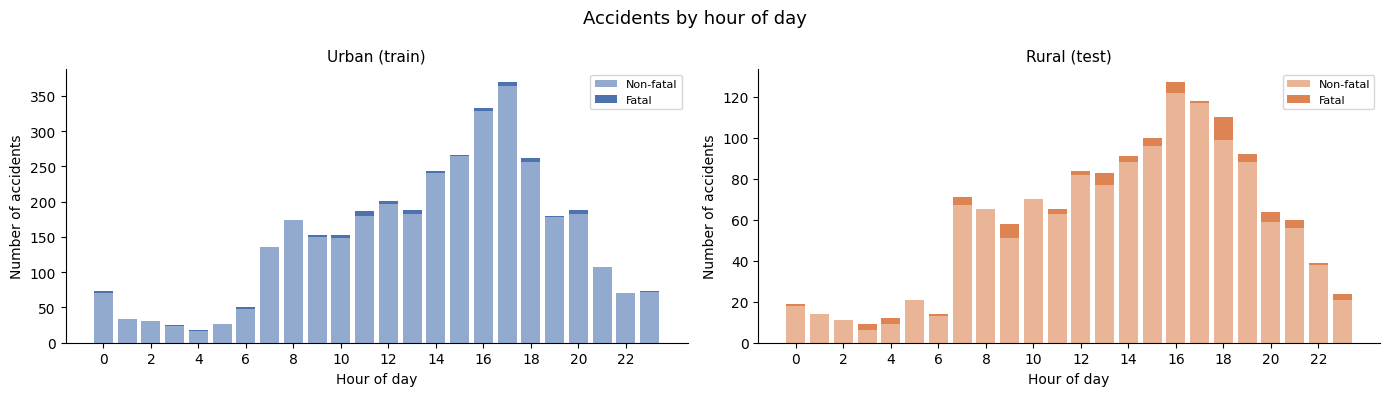

In [12]:
# Hour of day
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, (name, df) in zip(axes, datasets.items()):
    grp = df.groupby('hour').agg(
        total=('is_fatal', 'count'),
        fatal=('is_fatal', 'sum')
    ).reset_index()
    grp['non_fatal'] = grp['total'] - grp['fatal']
    ax.bar(grp['hour'], grp['non_fatal'], label='Non-fatal', color=colors[name], alpha=0.6)
    ax.bar(grp['hour'], grp['fatal'], bottom=grp['non_fatal'], label='Fatal', color=colors[name], alpha=1.0)
    ax.set_xlabel('Hour of day')
    ax.set_ylabel('Number of accidents')
    ax.set_title(name, fontsize=11)
    ax.set_xticks(range(0, 24, 2))
    ax.legend(fontsize=8)
    sns.despine(ax=ax)

plt.suptitle('Accidents by hour of day', fontsize=13)
plt.tight_layout()
plt.savefig('eda_05a_hourly.png', bbox_inches='tight')
plt.show()

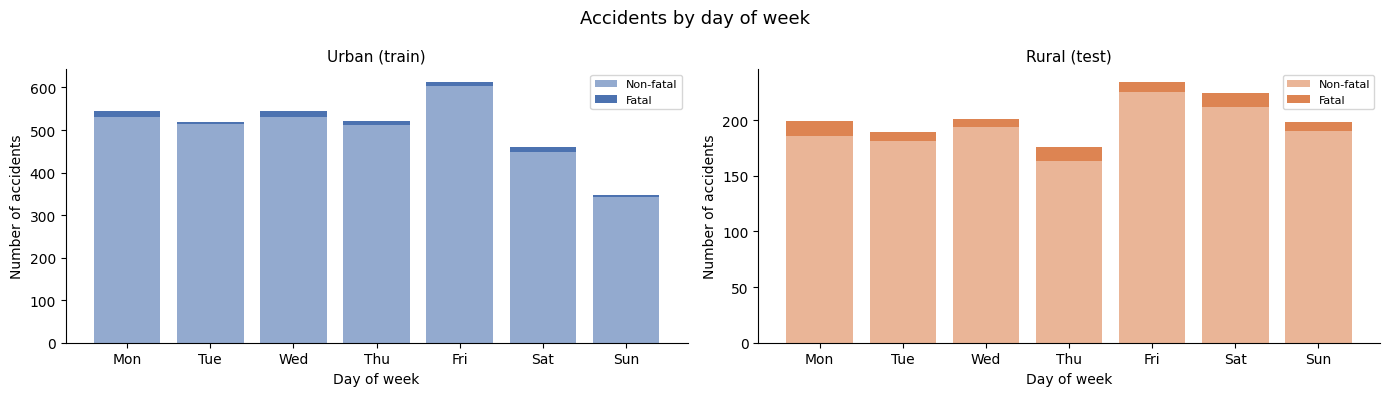

In [13]:
# Day of week
dow_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, (name, df) in zip(axes, datasets.items()):
    grp = df.groupby('day_of_week').agg(
        total=('is_fatal', 'count'),
        fatal=('is_fatal', 'sum')
    ).reset_index()
    grp['non_fatal'] = grp['total'] - grp['fatal']
    ax.bar(grp['day_of_week'], grp['non_fatal'], label='Non-fatal', color=colors[name], alpha=0.6)
    ax.bar(grp['day_of_week'], grp['fatal'], bottom=grp['non_fatal'], label='Fatal', color=colors[name], alpha=1.0)
    ax.set_xlabel('Day of week')
    ax.set_ylabel('Number of accidents')
    ax.set_title(name, fontsize=11)
    ax.set_xticks(range(7))
    ax.set_xticklabels(dow_labels)
    ax.legend(fontsize=8)
    sns.despine(ax=ax)

plt.suptitle('Accidents by day of week', fontsize=13)
plt.tight_layout()
plt.savefig('eda_05b_dayofweek.png', bbox_inches='tight')
plt.show()

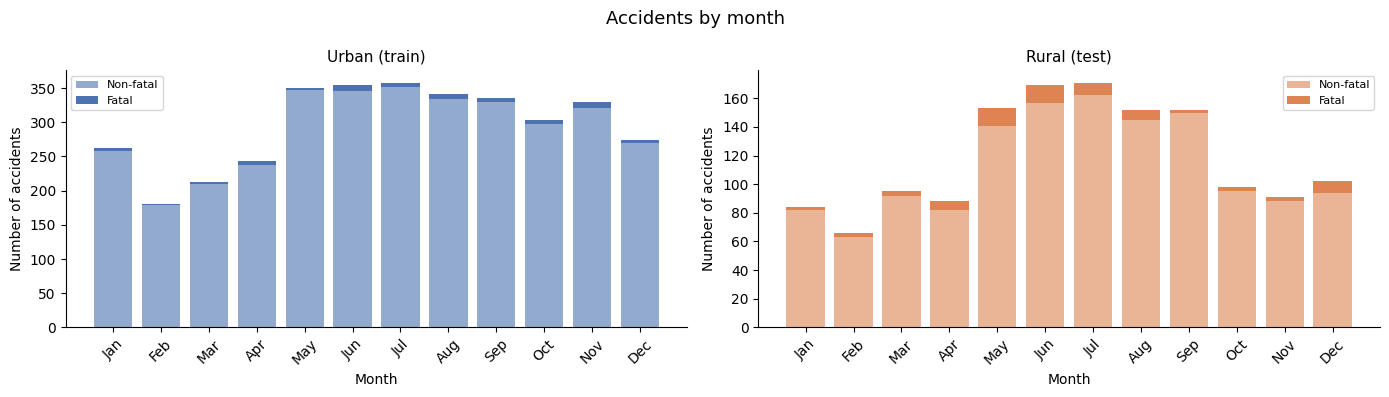

In [14]:
# Month
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, (name, df) in zip(axes, datasets.items()):
    grp = df.groupby('month').agg(
        total=('is_fatal', 'count'),
        fatal=('is_fatal', 'sum')
    ).reset_index()
    grp['non_fatal'] = grp['total'] - grp['fatal']
    ax.bar(grp['month'], grp['non_fatal'], label='Non-fatal', color=colors[name], alpha=0.6)
    ax.bar(grp['month'], grp['fatal'], bottom=grp['non_fatal'], label='Fatal', color=colors[name], alpha=1.0)
    ax.set_xlabel('Month')
    ax.set_ylabel('Number of accidents')
    ax.set_title(name, fontsize=11)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(month_labels, rotation=45)
    ax.legend(fontsize=8)
    sns.despine(ax=ax)

plt.suptitle('Accidents by month', fontsize=13)
plt.tight_layout()
plt.savefig('eda_05c_month.png', bbox_inches='tight')
plt.show()

## 7. Road Width

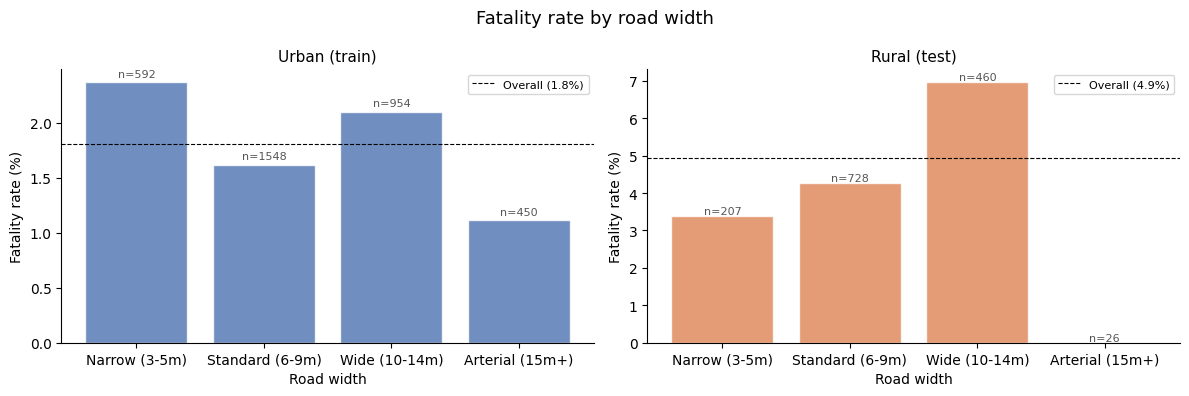

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (name, df) in zip(axes, datasets.items()):
    rate = (df.groupby('road_width_bin', observed=True)['is_fatal']
              .agg(['mean', 'count'])
              .rename(columns={'mean': 'fatality_rate', 'count': 'n'}))
    ax.bar(rate.index.astype(str), rate['fatality_rate'] * 100,
           color=colors[name], alpha=0.8, edgecolor='white')
    for x, (_, row) in enumerate(rate.iterrows()):
        ax.text(x, row['fatality_rate'] * 100 + 0.05,
                f'n={int(row["n"])}', ha='center', fontsize=8, color='#555')
    ax.axhline(df['is_fatal'].mean() * 100, color='black', linestyle='--',
               linewidth=0.8, label=f'Overall ({df["is_fatal"].mean():.1%})')
    ax.set_xlabel('Road width')
    ax.set_ylabel('Fatality rate (%)')
    ax.set_title(name, fontsize=11)
    ax.legend(fontsize=8)
    sns.despine(ax=ax)

plt.suptitle('Fatality rate by road width', fontsize=13)
plt.tight_layout()
plt.savefig('eda_06_road_width.png', bbox_inches='tight')
plt.show()

## 8. Speed Limit

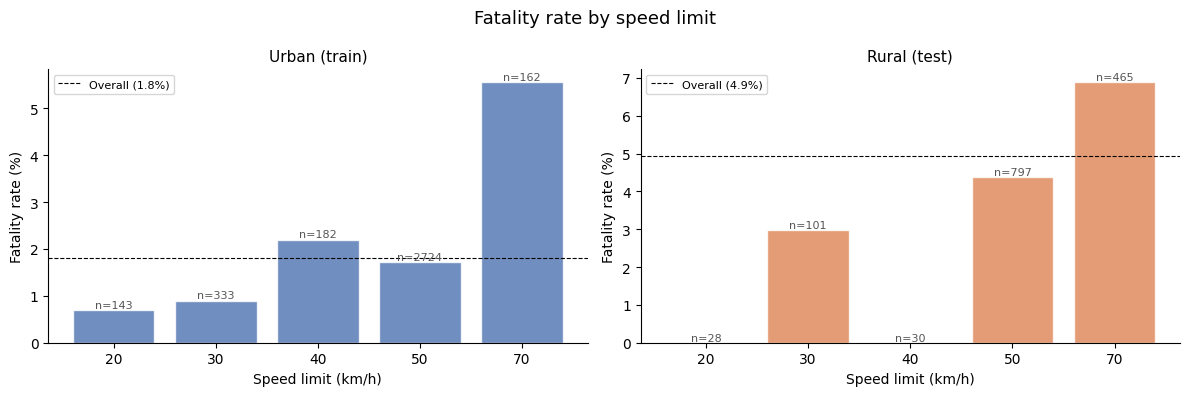

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (name, df) in zip(axes, datasets.items()):
    rate = (df.groupby('speed_limit')['is_fatal']
              .agg(['mean', 'count'])
              .rename(columns={'mean': 'fatality_rate', 'count': 'n'}))
    ax.bar(rate.index.astype(str), rate['fatality_rate'] * 100,
           color=colors[name], alpha=0.8, edgecolor='white')
    for x, (_, row) in enumerate(rate.iterrows()):
        ax.text(x, row['fatality_rate'] * 100 + 0.05,
                f'n={int(row["n"])}', ha='center', fontsize=8, color='#555')
    ax.axhline(df['is_fatal'].mean() * 100, color='black', linestyle='--',
               linewidth=0.8, label=f'Overall ({df["is_fatal"].mean():.1%})')
    ax.set_xlabel('Speed limit (km/h)')
    ax.set_ylabel('Fatality rate (%)')
    ax.set_title(name, fontsize=11)
    ax.legend(fontsize=8)
    sns.despine(ax=ax)

plt.suptitle('Fatality rate by speed limit', fontsize=13)
plt.tight_layout()
plt.savefig('eda_07_speed_limit.png', bbox_inches='tight')
plt.show()

## 9. Feature Shift Summary

In [17]:
summary = pd.DataFrame({
    'Urban (train)': [
        urban['speed_limit'].mean().round(1),
        urban['road_width'].mean().round(1),
        (urban['lighting'] == 'Pimeda aeg').mean().round(3),
        (urban['accident_type'] == 'Jalakäijaõnnetus').mean().round(3),
        (urban['accident_type'] == 'Ühesõidukiõnnetus').mean().round(3),
        urban['is_fatal'].mean().round(4),
    ],
    'Rural (test)': [
        rural['speed_limit'].mean().round(1),
        rural['road_width'].mean().round(1),
        (rural['lighting'] == 'Pimeda aeg').mean().round(3),
        (rural['accident_type'] == 'Jalakäijaõnnetus').mean().round(3),
        (rural['accident_type'] == 'Ühesõidukiõnnetus').mean().round(3),
        rural['is_fatal'].mean().round(4),
    ]
}, index=[
    'Mean speed limit (km/h)',
    'Mean road width (m)',
    '% dark conditions',
    '% pedestrian accidents',
    '% single-vehicle accidents',
    'Fatality rate'
])

summary

,Urban (train),Rural (test)
Mean speed limit (km/h),47.3000,54.3000
Mean road width (m),9.2000,8.3000
% dark conditions,0.2880,0.2390
% pedestrian accidents,0.3280,0.1250
% single-vehicle accidents,0.1150,0.3550
Fatality rate,0.0181,0.0493
